In [3]:
import pandas as pd, os

RACINE = os.path.abspath("../..")
DOSSIER_RETOURS = os.path.join(RACINE, "retours_celine")

# ── 1. Charger les deux fichiers tels quels ─────────────────
t1 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine.csv"),
                 engine="python", on_bad_lines="skip")
t2 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine_complet.csv"),
                 engine="python", on_bad_lines="skip")

print(f"validation_titres_celine          : {len(t1)} titres")
print(f"validation_titres_celine_complet  : {len(t2)} titres")

# ── 2. Combiner directement (pas de filtrage) ───────────────
combine = pd.concat([t1, t2], ignore_index=True)
print(f"  → total combiné : {len(combine)} titres\n")

# ── 3. Ne garder que les titres réellement annotés ──────────
combine["avis_celine"] = combine["avis_celine"].astype(str).str.strip().str.lower()
annotes = combine[combine["avis_celine"].isin(["valide", "invalide"])].copy()
print(f"Titres annotés (non vides) : {len(annotes)}")
print(f"  Vides exclus : {len(combine) - len(annotes)}\n")

# ── 4. Statistiques ─────────────────────────────────────────
print("=" * 50)
print("VALIDATION DES TITRES CLASSÉS CUIVRE (accord v1+v2+v3)")
print("=" * 50)
n_valide   = (annotes["avis_celine"] == "valide").sum()
n_invalide = (annotes["avis_celine"] == "invalide").sum()
total      = n_valide + n_invalide

print(f"  Total titres annotés : {total}")
print(f"  ✓ Corrects (valide)  : {n_valide} ({n_valide/total:.1%})")
print(f"  ✗ Incorrects         : {n_invalide} ({n_invalide/total:.1%})")

# Pondéré par nombre d'illustrations
if "nb_illustrations" in annotes.columns:
    annotes["nb_illustrations"] = pd.to_numeric(annotes["nb_illustrations"], errors="coerce").fillna(0)
    iv = annotes[annotes["avis_celine"]=="valide"]["nb_illustrations"].sum()
    ii = annotes[annotes["avis_celine"]=="invalide"]["nb_illustrations"].sum()
    it = iv + ii
    print(f"\n  En illustrations :")
    print(f"    ✓ Corrects   : {int(iv)} ({iv/it:.1%})")
    print(f"    ✗ Incorrects : {int(ii)} ({ii/it:.1%})")

# ── 5. Titres incorrects ────────────────────────────────────
if n_invalide > 0:
    print("\n" + "=" * 50)
    print("TITRES JUGÉS INCORRECTS")
    print("=" * 50)
    for _, row in annotes[annotes["avis_celine"]=="invalide"].iterrows():
        comm = row.get("commentaire", "")
        comm = f" — {comm}" if pd.notna(comm) and str(comm).strip() else ""
        print(f"  • {row['titre'][:70]}{comm}")

validation_titres_celine          : 118 titres
validation_titres_celine_complet  : 11 titres
  → total combiné : 129 titres

Titres annotés (non vides) : 116
  Vides exclus : 13

VALIDATION DES TITRES CLASSÉS CUIVRE (accord v1+v2+v3)
  Total titres annotés : 116
  ✓ Corrects (valide)  : 110 (94.8%)
  ✗ Incorrects         : 6 (5.2%)

  En illustrations :
    ✓ Corrects   : 432 (94.1%)
    ✗ Incorrects : 27 (5.9%)

TITRES JUGÉS INCORRECTS
  • [Illustrations de Cosmographie universelle] / [Non identifié] ; André 
  • [Illustrations de Les Métamorphoses] / [Non identifié] ; Ovide, aut. d — iconographie super pertinente ! 
  • [Illustrations de De Re mtallica libri XII. ..] / [Non identifié] ; Ge
  • [L'Apocalypse]. 15, [La Grande prostituée de Babylone, édition latine 
  • [Illustrations de Orlando furioso] / [Non identifié] ; Ludovico Ariost
  • [Illustrations de Les Métamorphoses] / Georges Wickram, grav. ; Ovide,


In [4]:
import pandas as pd, os

RACINE = os.path.abspath("../..")
DOSSIER_RETOURS = os.path.join(RACINE, "retours_celine")

t1 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine.csv"),
                 engine="python", on_bad_lines="skip")
t2 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine_complet.csv"),
                 engine="python", on_bad_lines="skip")

# Combiner, en privilégiant le fichier complet pour les titres présents dans les deux
combine = pd.concat([t2, t1], ignore_index=True)
combine = combine.drop_duplicates(subset=["titre"], keep="first")  # garde la version de t2
print(f"Titres uniques combinés : {len(combine)}")

# Normaliser
combine["avis_celine"]  = combine["avis_celine"].astype(str).str.strip().str.lower()
combine["commentaire"]  = combine["commentaire"].astype(str).fillna("")

# Marquer les douteux (?? dans le commentaire)
combine["douteux"] = combine["commentaire"].str.contains(r"\?\?", regex=True, na=False)

# Garder seulement valide/invalide ET non douteux
annotes = combine[
    combine["avis_celine"].isin(["valide", "invalide"]) &
    (~combine["douteux"])
].copy()

print(f"Titres annotés fermes (hors ?? et vides) : {len(annotes)}")
print(f"  Exclus (vides ou douteux) : {len(combine) - len(annotes)}\n")

# ── Statistiques ────────────────────────────────────────────
n_valide   = (annotes["avis_celine"] == "valide").sum()
n_invalide = (annotes["avis_celine"] == "invalide").sum()
total      = n_valide + n_invalide

print("=" * 50)
print("VALIDATION TITRES CUIVRE (accord v1+v2+v3) — avis fermes")
print("=" * 50)
print(f"  Total titres fermes : {total}")
print(f"  ✓ Corrects   : {n_valide} ({n_valide/total:.1%})")
print(f"  ✗ Incorrects : {n_invalide} ({n_invalide/total:.1%})")

annotes["nb_illustrations"] = pd.to_numeric(annotes["nb_illustrations"], errors="coerce").fillna(0)
iv = annotes[annotes["avis_celine"]=="valide"]["nb_illustrations"].sum()
ii = annotes[annotes["avis_celine"]=="invalide"]["nb_illustrations"].sum()
print(f"\n  En illustrations :")
print(f"    ✓ Corrects   : {int(iv)} ({iv/(iv+ii):.1%})")
print(f"    ✗ Incorrects : {int(ii)} ({ii/(iv+ii):.1%})")

print("\n  Titres jugés incorrects :")
for _, r in annotes[annotes["avis_celine"]=="invalide"].iterrows():
    print(f"    • {r['titre'][:65]}")

Titres uniques combinés : 120
Titres annotés fermes (hors ?? et vides) : 103
  Exclus (vides ou douteux) : 17

VALIDATION TITRES CUIVRE (accord v1+v2+v3) — avis fermes
  Total titres fermes : 103
  ✓ Corrects   : 98 (95.1%)
  ✗ Incorrects : 5 (4.9%)

  En illustrations :
    ✓ Corrects   : 328 (92.9%)
    ✗ Incorrects : 25 (7.1%)

  Titres jugés incorrects :
    • [Illustrations de Orlando furioso] / [Non identifié] ; Ludovico A
    • [Illustrations de Les Métamorphoses] / Georges Wickram, grav. ; O
    • [Illustrations de Les Métamorphoses] / [Non identifié] ; Ovide, a
    • [Illustrations de De Re mtallica libri XII. ..] / [Non identifié]
    • [L'Apocalypse]. 15, [La Grande prostituée de Babylone, édition la


In [5]:
import pandas as pd, os

RACINE = os.path.abspath("../..")
DOSSIER_RETOURS = os.path.join(RACINE, "retours_celine")

t1 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine.csv"),
                 engine="python", on_bad_lines="skip")
t2 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine_complet.csv"),
                 engine="python", on_bad_lines="skip")

combine = pd.concat([t1, t2], ignore_index=True)
combine["nb_illustrations"] = pd.to_numeric(combine["nb_illustrations"], errors="coerce").fillna(0)

# Trier par nb_illustrations décroissant puis garder la 1re occurrence de chaque titre
# → on conserve la version avec le PLUS GRAND nombre d'illustrations
combine = (combine.sort_values("nb_illustrations", ascending=False)
                  .drop_duplicates(subset=["titre"], keep="first")
                  .reset_index(drop=True))
print(f"Titres uniques combinés : {len(combine)}")

# Normaliser
combine["avis_celine"] = combine["avis_celine"].astype(str).str.strip().str.lower()
combine["commentaire"] = combine["commentaire"].astype(str).fillna("")
combine["douteux"]     = combine["commentaire"].str.contains(r"\?\?", regex=True, na=False)

annotes = combine[
    combine["avis_celine"].isin(["valide", "invalide"]) &
    (~combine["douteux"])
].copy()

print(f"Titres annotés fermes (hors ?? et vides) : {len(annotes)}")
print(f"  Exclus (vides ou douteux) : {len(combine) - len(annotes)}\n")

# ── Statistiques ────────────────────────────────────────────
n_valide   = (annotes["avis_celine"] == "valide").sum()
n_invalide = (annotes["avis_celine"] == "invalide").sum()
total      = n_valide + n_invalide

print("=" * 50)
print("VALIDATION TITRES CUIVRE (accord v1+v2+v3) — avis fermes")
print("=" * 50)
print(f"  Total titres fermes : {total}")
print(f"  ✓ Corrects   : {n_valide} ({n_valide/total:.1%})")
print(f"  ✗ Incorrects : {n_invalide} ({n_invalide/total:.1%})")

iv = annotes[annotes["avis_celine"]=="valide"]["nb_illustrations"].sum()
ii = annotes[annotes["avis_celine"]=="invalide"]["nb_illustrations"].sum()
print(f"\n  En illustrations :")
print(f"    ✓ Corrects   : {int(iv)} ({iv/(iv+ii):.1%})")
print(f"    ✗ Incorrects : {int(ii)} ({ii/(iv+ii):.1%})")

print("\n  Titres jugés incorrects :")
for _, r in annotes[annotes["avis_celine"]=="invalide"].iterrows():
    print(f"    • {r['titre'][:65]} ({int(r['nb_illustrations'])} illustr.)")

Titres uniques combinés : 120
Titres annotés fermes (hors ?? et vides) : 103
  Exclus (vides ou douteux) : 17

VALIDATION TITRES CUIVRE (accord v1+v2+v3) — avis fermes
  Total titres fermes : 103
  ✓ Corrects   : 98 (95.1%)
  ✗ Incorrects : 5 (4.9%)

  En illustrations :
    ✓ Corrects   : 328 (92.9%)
    ✗ Incorrects : 25 (7.1%)

  Titres jugés incorrects :
    • [Illustrations de Orlando furioso] / [Non identifié] ; Ludovico A (17 illustr.)
    • [Illustrations de Les Métamorphoses] / Georges Wickram, grav. ; O (5 illustr.)
    • [Illustrations de Les Métamorphoses] / [Non identifié] ; Ovide, a (1 illustr.)
    • [Illustrations de De Re mtallica libri XII. ..] / [Non identifié] (1 illustr.)
    • [L'Apocalypse]. 15, [La Grande prostituée de Babylone, édition la (1 illustr.)


In [6]:
import pandas as pd, os

RACINE = os.path.abspath("../..")
DOSSIER_RETOURS = os.path.join(RACINE, "retours_celine")

# ── Charger les annotations de désaccords ───────────────────
des = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_celine_desaccords_complet.csv"))
des = des[des["avis_celine"].isin(["bois", "cuivre"])].copy()

n = len(des)
print("=" * 55)
print(f"STATS DÉSACCORDS — {n} illustrations annotées par Céline")
print("=" * 55)
print(f"Répartition réelle (avis Céline) : "
      f"{(des['avis_celine']=='cuivre').sum()} cuivre, "
      f"{(des['avis_celine']=='bois').sum()} bois\n")

# ── 1. Accuracy par version ─────────────────────────────────
print("ACCURACY DE CHAQUE VERSION")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    c = (des[v] == des["avis_celine"]).sum()
    print(f"  {v} : {c/n:.1%}  ({c}/{n})")

# ── 2. Qui tranche juste sur les désaccords ─────────────────
for v in ["v1", "v2", "v3"]:
    des[f"{v}_ok"] = des[v] == des["avis_celine"]

seuls = {
    "v1": des[des["v1_ok"] & ~des["v2_ok"] & ~des["v3_ok"]],
    "v2": des[des["v2_ok"] & ~des["v1_ok"] & ~des["v3_ok"]],
    "v3": des[des["v3_ok"] & ~des["v1_ok"] & ~des["v2_ok"]],
}
print("\nQUI A RAISON QUAND ELLE EST SEULE À TRANCHER")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    print(f"  {v} seule a raison : {len(seuls[v])}")

# ── 3. Nature des erreurs ───────────────────────────────────
print("\nNATURE DES ERREURS")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    err = des[des[v] != des["avis_celine"]]
    rates = len(err[(err[v]=="bois") & (err["avis_celine"]=="cuivre")])
    faux  = len(err[(err[v]=="cuivre") & (err["avis_celine"]=="bois")])
    print(f"  {v} — {len(err)} erreurs : {rates} cuivres ratés, {faux} faux cuivres")

STATS DÉSACCORDS — 319 illustrations annotées par Céline
Répartition réelle (avis Céline) : 193 cuivre, 126 bois

ACCURACY DE CHAQUE VERSION
-------------------------------------------------------
  v1 : 59.9%  (191/319)
  v2 : 49.2%  (157/319)
  v3 : 60.2%  (192/319)

QUI A RAISON QUAND ELLE EST SEULE À TRANCHER
-------------------------------------------------------
  v1 seule a raison : 10
  v2 seule a raison : 17
  v3 seule a raison : 69

NATURE DES ERREURS
-------------------------------------------------------
  v1 — 128 erreurs : 112 cuivres ratés, 14 faux cuivres
  v2 — 162 erreurs : 148 cuivres ratés, 11 faux cuivres
  v3 — 127 erreurs : 9 cuivres ratés, 116 faux cuivres


In [7]:
import pandas as pd, os

RACINE = os.path.abspath("../..")
des = pd.read_csv(os.path.join(RACINE, "retours_celine", "validation_celine_desaccords_complet.csv"))
des = des[des["avis_celine"].isin(["bois", "cuivre"])].copy()
n = len(des)

print("=" * 55)
print(f"STATS DÉSACCORDS — {n} illustrations annotées par Céline")
print("=" * 55)
print(f"Répartition réelle (avis Céline) : "
      f"{(des.avis_celine=='cuivre').sum()} cuivre, {(des.avis_celine=='bois').sum()} bois\n")

print("ACCURACY DE CHAQUE VERSION")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    c = (des[v] == des.avis_celine).sum()
    print(f"  {v} : {c/n:.1%}  ({c}/{n})")

print("\nCUIVRE DÉTECTÉ ET PRÉCISION (sur les désaccords)")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    det  = (des[v] == "cuivre").sum()
    vrai = ((des[v] == "cuivre") & (des.avis_celine == "cuivre")).sum()
    print(f"  {v} : {det} cuivres détectés, {vrai} validés vrais ({vrai/det:.1%})")

STATS DÉSACCORDS — 319 illustrations annotées par Céline
Répartition réelle (avis Céline) : 193 cuivre, 126 bois

ACCURACY DE CHAQUE VERSION
-------------------------------------------------------
  v1 : 59.9%  (191/319)
  v2 : 49.2%  (157/319)
  v3 : 60.2%  (192/319)

CUIVRE DÉTECTÉ ET PRÉCISION (sur les désaccords)
-------------------------------------------------------
  v1 : 95 cuivres détectés, 81 validés vrais (85.3%)
  v2 : 56 cuivres détectés, 45 validés vrais (80.4%)
  v3 : 298 cuivres détectés, 182 validés vrais (61.1%)


In [10]:
import pandas as pd, os

RACINE = os.path.abspath("../..")
DOSSIER_RETOURS = os.path.join(RACINE, "retours_celine")

# ===== 1. DÉSACCORDS (avis par illustration) =====
des = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_celine_desaccords_complet.csv"))
des = des[des["avis_celine"].isin(["bois", "cuivre"])].copy()
n = len(des)

print("=" * 55)
print(f"STATS DÉSACCORDS — {n} illustrations annotées")
print("=" * 55)
print(f"Répartition réelle : "
      f"{(des.avis_celine=='cuivre').sum()} cuivre, {(des.avis_celine=='bois').sum()} bois\n")

print("ACCURACY DE CHAQUE VERSION")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    c = (des[v] == des.avis_celine).sum()
    print(f"  {v} : {c/n:.1%}  ({c}/{n})")

print("\nCUIVRE DÉTECTÉ ET PRÉCISION (sur les désaccords)")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    det  = (des[v] == "cuivre").sum()
    vrai = ((des[v] == "cuivre") & (des.avis_celine == "cuivre")).sum()
    print(f"  {v} : {det} cuivres détectés, {vrai} validés vrais ({vrai/det:.1%})")

# ===== 2. ACCORDS (par titre, avis fermes, pondéré nb_illustrations) =====
t1 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine.csv"),
                 engine="python", on_bad_lines="skip")
t2 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine_complet.csv"),
                 engine="python", on_bad_lines="skip")
tit = pd.concat([t1, t2], ignore_index=True)
tit["nb_illustrations"] = pd.to_numeric(tit["nb_illustrations"], errors="coerce").fillna(0)
tit = tit.sort_values("nb_illustrations", ascending=False).drop_duplicates("titre", keep="first")
tit["avis_celine"] = tit["avis_celine"].astype(str).str.strip().str.lower()
tit["douteux"] = tit["commentaire"].astype(str).str.contains(r"\?\?", regex=True, na=False)
tit = tit[tit["avis_celine"].isin(["valide", "invalide"]) & ~tit["douteux"]]
acc_vrai  = tit[tit.avis_celine == "valide"]["nb_illustrations"].sum()
acc_total = tit["nb_illustrations"].sum()

# ===== 3. PRÉCISION CUIVRE GLOBALE (désaccords + accords) =====
print("\n" + "=" * 55)
print("PRÉCISION CUIVRE GLOBALE (désaccords + accords)")
print("=" * 55)
print(f"  (accords communs aux 3 versions : {int(acc_vrai)}/{int(acc_total)} vrais)")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    d_det  = (des[v] == "cuivre").sum()
    d_vrai = ((des[v] == "cuivre") & (des.avis_celine == "cuivre")).sum()
    g_vrai = d_vrai + acc_vrai
    g_det  = d_det + acc_total
    print(f"  {v} : {int(g_vrai)}/{int(g_det)} vrais cuivres ({g_vrai/g_det:.1%})")

STATS DÉSACCORDS — 319 illustrations annotées
Répartition réelle : 193 cuivre, 126 bois

ACCURACY DE CHAQUE VERSION
-------------------------------------------------------
  v1 : 59.9%  (191/319)
  v2 : 49.2%  (157/319)
  v3 : 60.2%  (192/319)

CUIVRE DÉTECTÉ ET PRÉCISION (sur les désaccords)
-------------------------------------------------------
  v1 : 95 cuivres détectés, 81 validés vrais (85.3%)
  v2 : 56 cuivres détectés, 45 validés vrais (80.4%)
  v3 : 298 cuivres détectés, 182 validés vrais (61.1%)

PRÉCISION CUIVRE GLOBALE (désaccords + accords)
  (accords communs aux 3 versions : 328/353 vrais)
-------------------------------------------------------
  v1 : 409/448 vrais cuivres (91.3%)
  v2 : 373/409 vrais cuivres (91.2%)
  v3 : 510/651 vrais cuivres (78.3%)


Version  Accuracy_désaccords  Précision  Rappel    F1  Vrais_cuivres  Détectés_cuivre
     V1                0.599      0.913   0.785 0.844            409              448
     V2                0.492      0.912   0.716 0.802            373              409
     V3                0.602      0.783   0.979 0.870            510              651

✓ Tableau sauvegardé : /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/resultats/csv/metriques_v1v2v3.csv


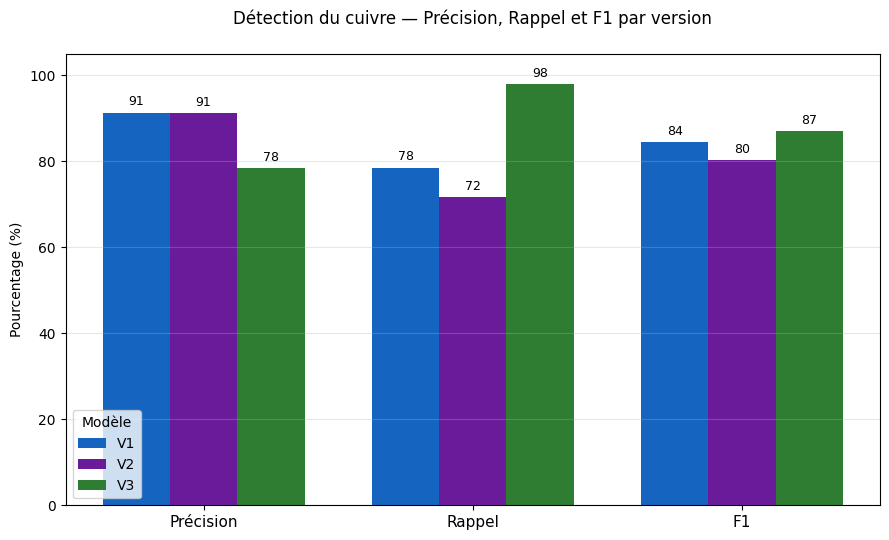

✓ Graphique sauvegardé : /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/resultats/visualisations/metriques_v1v2v3.png


In [12]:
import pandas as pd, os
import matplotlib.pyplot as plt
import numpy as np

RACINE = os.path.abspath("../..")
DOSSIER_RETOURS = os.path.join(RACINE, "retours_celine")
DOSSIER_VIZ     = os.path.join(RACINE, "resultats", "Datavis")
os.makedirs(DOSSIER_VIZ, exist_ok=True)

# ===== Recalcul des métriques =====
des = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_celine_desaccords_complet.csv"))
des = des[des["avis_celine"].isin(["bois", "cuivre"])].copy()

t1 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine.csv"),
                 engine="python", on_bad_lines="skip")
t2 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine_complet.csv"),
                 engine="python", on_bad_lines="skip")
tit = pd.concat([t1, t2], ignore_index=True)
tit["nb_illustrations"] = pd.to_numeric(tit["nb_illustrations"], errors="coerce").fillna(0)
tit = tit.sort_values("nb_illustrations", ascending=False).drop_duplicates("titre", keep="first")
tit["avis_celine"] = tit["avis_celine"].astype(str).str.strip().str.lower()
tit["douteux"] = tit["commentaire"].astype(str).str.contains(r"\?\?", regex=True, na=False)
tit = tit[tit["avis_celine"].isin(["valide", "invalide"]) & ~tit["douteux"]]
acc_vrai = tit[tit.avis_celine == "valide"]["nb_illustrations"].sum()
acc_tot  = tit["nb_illustrations"].sum()
total_vrais = (des.avis_celine == "cuivre").sum() + acc_vrai

rows = []
for v in ["v1", "v2", "v3"]:
    n = len(des)
    acc = (des[v] == des.avis_celine).sum() / n
    d_vrai = ((des[v] == "cuivre") & (des.avis_celine == "cuivre")).sum()
    retr = d_vrai + acc_vrai
    det  = (des[v] == "cuivre").sum() + acc_tot
    prec = retr / det
    rapp = retr / total_vrais
    f1   = 2 * prec * rapp / (prec + rapp)
    rows.append({
        "Version": v.upper(),
        "Accuracy_désaccords": round(acc, 3),
        "Précision": round(prec, 3),
        "Rappel": round(rapp, 3),
        "F1": round(f1, 3),
        "Vrais_cuivres": int(retr),
        "Détectés_cuivre": int(det),
    })

recap = pd.DataFrame(rows)
print(recap.to_string(index=False))

# ===== Sauvegarder le tableau en CSV =====
chemin_csv = os.path.join(RACINE, "resultats", "csv", "metriques_v1v2v3.csv")
recap.to_csv(chemin_csv, index=False, encoding="utf-8-sig")
print(f"\n✓ Tableau sauvegardé : {chemin_csv}")

# ===== Graphique en barres groupées =====
fig, ax = plt.subplots(figsize=(9, 5.5))
metriques = ["Précision", "Rappel", "F1"]
x = np.arange(len(metriques))
largeur = 0.25
couleurs = {"V1": "#1565c0", "V2": "#6a1b9a", "V3": "#2e7d32"}

for i, v in enumerate(["V1", "V2", "V3"]):
    valeurs = [recap[recap.Version == v][m].values[0] * 100 for m in metriques]
    barres = ax.bar(x + (i - 1) * largeur, valeurs, largeur,
                    label=v, color=couleurs[v])
    for b, val in zip(barres, valeurs):
        ax.text(b.get_x() + b.get_width()/2, val + 1, f"{val:.0f}",
                ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Pourcentage (%)")
ax.set_title("Détection du cuivre — Précision, Rappel et F1 par version\n"
            , fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metriques, fontsize=11)
ax.set_ylim(0, 105)
ax.legend(title="Modèle")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

chemin_png = os.path.join(DOSSIER_VIZ, "metriques_v1v2v3.png")
plt.savefig(chemin_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Graphique sauvegardé : {chemin_png}")